# Input Validation: Funafuti DEM and Population Raster

This notebook checks the processed ASTER DEM and WorldPop raster before the
exposure analysis runs.

Status codes:

- `PASS`: acceptable
- `INFO`: expected difference handled later
- `WARN`: known limitation to report
- `FAIL`: stop and fix before analysis

Checks cover CRS, extent, grid alignment, elevation range, population total and
the contextual statistics file used by the website.

## 1. Setup

In [1]:
import json
import rasterio
from rasterio.warp import transform_bounds
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DEM_PATH = PROJECT_ROOT / "data" / "raw" / "tuvalu_dem_funafuti_admin.tif"
POP_PATH = PROJECT_ROOT / "data" / "raw" / "tuvalu_pop_funafuti_admin.tif"
CONTEXT_STATS_PATH = PROJECT_ROOT / "data" / "reference" / "context_stats.json"

FUNAFUTI_LIDAR_MAX_M = 6.93
FUNAFUTI_LIDAR_MEAN_M = 1.48
ELEVATION_WARNING_MULTIPLIER = 3
ELEVATION_HARD_FAIL_M = 100.0

KNOWN_FUNAFUTI_POPULATION_2017 = 6320
POPULATION_TOLERANCE = 0.5

print("DEM path:", DEM_PATH, "exists:", DEM_PATH.exists())
print("Population path:", POP_PATH, "exists:", POP_PATH.exists())
print("Context stats:", CONTEXT_STATS_PATH, "exists:", CONTEXT_STATS_PATH.exists())

results = {}

def record_check(key, status, label, detail="", blocking=False):
    if status not in {"PASS", "INFO", "WARN", "FAIL"}:
        raise ValueError(f"Unknown validation status: {status}")
    results[key] = {
        "status": status,
        "label": label,
        "detail": detail,
        "blocking": blocking,
    }
    print(f"{status:<4}  {label}" + (f"  -- {detail}" if detail else ""))
    return status

DEM path: ..\data\raw\tuvalu_dem_funafuti_admin.tif exists: True
Population path: ..\data\raw\tuvalu_pop_funafuti_admin.tif exists: True
Context stats: ..\data\reference\context_stats.json exists: True


## 2. Open rasters

In [2]:
dem_src = rasterio.open(DEM_PATH)
pop_src = rasterio.open(POP_PATH)

print("DEM  :", dem_src.crs, dem_src.shape, dem_src.res)
print("Pop  :", pop_src.crs, pop_src.shape, pop_src.res)

DEM  : EPSG:3832 (3554, 3939) (30.819197846428175, 30.819197846428498)
Pop  : EPSG:4326 (1323, 1309) (0.00083333333, 0.00083333333)


## 3. Coordinate reference systems

ASTER and WorldPop may use different native CRSs. The population raster is
reprojected to the DEM grid in `01_flood_exposure_analysis.ipynb`.

In [3]:
crs_match = dem_src.crs == pop_src.crs
record_check(
    "crs_match",
    "PASS" if crs_match else "INFO",
    "Native coordinate reference systems",
    f"DEM: {dem_src.crs} | Population: {pop_src.crs}" +
    (" | already aligned" if crs_match else
     " | different by design; population is reprojected to the DEM grid during analysis"),
    blocking=False,
)


INFO  Native coordinate reference systems  -- DEM: EPSG:3832 | Population: EPSG:4326 | different by design; population is reprojected to the DEM grid during analysis


'INFO'

## 4. Geographic overlap

Bounds are compared in the DEM CRS so that metre and degree coordinates are
not compared directly.

In [4]:
dem_bounds = dem_src.bounds
pop_bounds_in_dem_crs = transform_bounds(pop_src.crs, dem_src.crs, *pop_src.bounds)

overlap = not (
    dem_bounds.right < pop_bounds_in_dem_crs[0] or dem_bounds.left > pop_bounds_in_dem_crs[2] or
    dem_bounds.top < pop_bounds_in_dem_crs[1] or dem_bounds.bottom > pop_bounds_in_dem_crs[3]
)
record_check(
    "extent_overlap",
    "PASS" if overlap else "FAIL",
    "Geographic extents overlap (compared in a common CRS)",
    f"DEM bounds ({dem_src.crs}): {tuple(round(b,2) for b in dem_bounds)} | "
    f"Population bounds reprojected to {dem_src.crs}: {tuple(round(b,2) for b in pop_bounds_in_dem_crs)}",
    blocking=True,
)
if not overlap:
    print("   -> No overlap at all -- very likely the wrong region was downloaded "
          "(e.g. one covers the whole Pacific, the other only Funafuti atoll).")


PASS  Geographic extents overlap (compared in a common CRS)  -- DEM bounds (EPSG:3832): (3181246.66, -999388.9, 3302643.48, -889857.48) | Population bounds reprojected to EPSG:3832: (3181232.59, -1013153.41, 3302663.6, -889847.72)


The plot provides a quick visual check of the two extents.

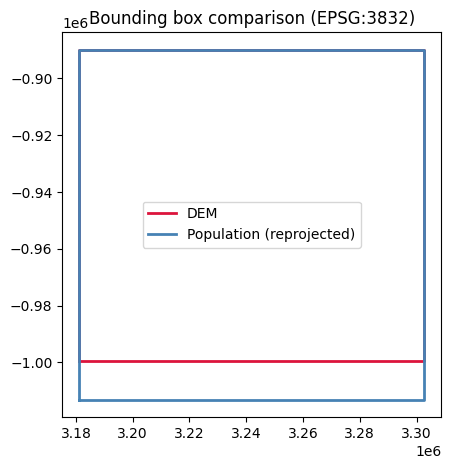

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
def plot_bbox(bounds, label, color):
    x = [bounds[0], bounds[2], bounds[2], bounds[0], bounds[0]]
    y = [bounds[1], bounds[1], bounds[3], bounds[3], bounds[1]]
    ax.plot(x, y, color=color, label=label, linewidth=2)

plot_bbox(dem_bounds, "DEM", "crimson")
plot_bbox(pop_bounds_in_dem_crs, "Population (reprojected)", "steelblue")
ax.set_title(f"Bounding box comparison ({dem_src.crs})")
ax.legend()
ax.set_aspect("equal")
plt.show()

## 5. Native grids

Different grid size and resolution are expected. WorldPop is aligned to the
ASTER grid during the analysis.

In [6]:
dem_res = dem_src.res
pop_res = pop_src.res

# These native resolutions are expressed in different CRS units (metres vs.
# degrees), so a direct numeric equality test is not scientifically meaningful.
# What matters is whether the grids are already identical; if not, the formal
# analysis explicitly reprojects/resamples WorldPop onto the DEM grid.
grid_already_aligned = (
    dem_src.crs == pop_src.crs and
    dem_src.transform == pop_src.transform and
    dem_src.width == pop_src.width and
    dem_src.height == pop_src.height
)

record_check(
    "native_grid_alignment",
    "PASS" if grid_already_aligned else "INFO",
    "Native raster grid alignment",
    f"DEM resolution: {dem_res} ({dem_src.crs}) | Population resolution: {pop_res} ({pop_src.crs})" +
    (" | grids already identical" if grid_already_aligned else
     " | different by design; nearest-neighbour reprojection/resampling is required downstream"),
    blocking=False,
)


INFO  Native raster grid alignment  -- DEM resolution: (30.819197846428175, 30.819197846428498) (EPSG:3832) | Population resolution: (0.00083333333, 0.00083333333) (EPSG:4326) | different by design; nearest-neighbour reprojection/resampling is required downstream


'INFO'

## 6. Elevation range

The ASTER maximum is compared with recent LiDAR topography for context.
Wandres et al. (2024) report a Funafuti maximum of 6.93 m above MSL and a
Funafuti mean of 1.48 m. The paper notes that the maximum is associated with
human-modified ground.

ASTER can contain much larger vertical errors over low coral atolls. A high
ASTER maximum is therefore recorded as a warning unless it exceeds the hard
project QA limit of 100 m.

In [7]:
dem = dem_src.read(1)
dem_nodata = dem_src.nodata
valid_dem = dem[(dem != dem_nodata)] if dem_nodata is not None else dem
land_dem = valid_dem[valid_dem > 0]

if land_dem.size > 0:
    max_elev = float(land_dem.max())
    warning_threshold = FUNAFUTI_LIDAR_MAX_M * ELEVATION_WARNING_MULTIPLIER

    if max_elev >= ELEVATION_HARD_FAIL_M:
        elevation_status = "FAIL"
        elevation_blocking = True
        elevation_note = (
            f"ASTER max {max_elev:.2f} m exceeds the project hard limit "
            f"of {ELEVATION_HARD_FAIL_M:.0f} m. Re-check units, source and clipping."
        )
    elif max_elev > warning_threshold:
        elevation_status = "WARN"
        elevation_blocking = False
        elevation_note = (
            f"ASTER max {max_elev:.2f} m is well above the 6.93 m Funafuti "
            "LiDAR maximum reported by Wandres et al. (2024). Treat threshold "
            "results as screening-level elevation exposure."
        )
    else:
        elevation_status = "PASS"
        elevation_blocking = False
        elevation_note = (
            f"ASTER max {max_elev:.2f} m; Funafuti LiDAR reference max "
            f"{FUNAFUTI_LIDAR_MAX_M:.2f} m, mean {FUNAFUTI_LIDAR_MEAN_M:.2f} m."
        )

    record_check(
        "elevation_sanity",
        elevation_status,
        "Elevation range",
        elevation_note,
        blocking=elevation_blocking,
    )
else:
    record_check(
        "elevation_sanity",
        "FAIL",
        "Elevation range",
        "No land pixels above 0 m were found.",
        blocking=True,
    )

WARN  Elevation range  -- ASTER max 41.00 m is well above the 6.93 m Funafuti LiDAR maximum reported by Wandres et al. (2024). Treat threshold results as screening-level elevation exposure.


The DEM plot is cropped to the land extent so that isolated high pixels can be inspected.

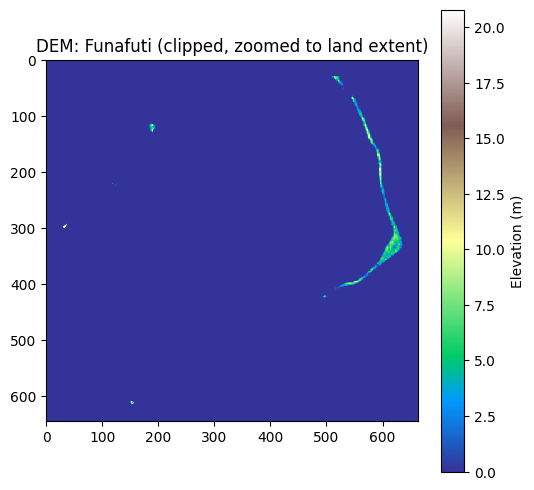

In [8]:
dem_land_mask = (dem > 0) & (dem != dem_nodata)
land_rows, land_cols = np.where(dem_land_mask)
pad = max(15, int(0.05 * max(land_rows.max() - land_rows.min(), land_cols.max() - land_cols.min())))
row_min, row_max = max(0, land_rows.min() - pad), min(dem.shape[0], land_rows.max() + pad)
col_min, col_max = max(0, land_cols.min() - pad), min(dem.shape[1], land_cols.max() + pad)

fig, ax = plt.subplots(figsize=(6, 6))
dem_display = np.where(dem == dem_nodata, np.nan, dem)
cropped = dem_display[row_min:row_max, col_min:col_max]
im = ax.imshow(cropped, cmap="terrain", vmax=max(FUNAFUTI_LIDAR_MAX_M * 3, 20), interpolation="nearest")
ax.set_title("DEM: Funafuti (clipped, zoomed to land extent)")
plt.colorbar(im, ax=ax, label="Elevation (m)")
plt.show()

## 7. Population total

The native WorldPop total is compared with Funafuti's 2017 resident population
of 6,320 as an order-of-magnitude check. WorldPop is a modelled surface, so the
census count is not treated as an equivalent observation.

In [9]:
pop = pop_src.read(1)
pop_nodata = pop_src.nodata
valid_pop = pop[(pop != pop_nodata)] if pop_nodata is not None else pop
valid_pop = valid_pop[valid_pop > 0]
total_pop = float(valid_pop.sum())

lower = KNOWN_FUNAFUTI_POPULATION_2017 * (1 - POPULATION_TOLERANCE)
upper = KNOWN_FUNAFUTI_POPULATION_2017 * (1 + POPULATION_TOLERANCE)
pop_reasonable = lower <= total_pop <= upper

record_check(
    "population_reasonable",
    "PASS" if pop_reasonable else "FAIL",
    "Native-resolution WorldPop total is a reasonable order of magnitude",
    f"Raster total population: {total_pop:,.0f} (reference: Funafuti's resident population was "
    f"{KNOWN_FUNAFUTI_POPULATION_2017:,} at the 2017 census; +/-50% validation tolerance)",
    blocking=True,
)
if not pop_reasonable:
    print("   -> Common causes: the clipped boundary extends beyond Funafuti, the wrong "
          "WorldPop year was selected, or nodata sentinel values (e.g. -99999) were not "
          "excluded before summing -- this silently produced large negative population "
          "totals earlier in this project, so check explicitly.")

PASS  Native-resolution WorldPop total is a reasonable order of magnitude  -- Raster total population: 6,320 (reference: Funafuti's resident population was 6,320 at the 2017 census; +/-50% validation tolerance)


The population plot is cropped to the valid data extent.

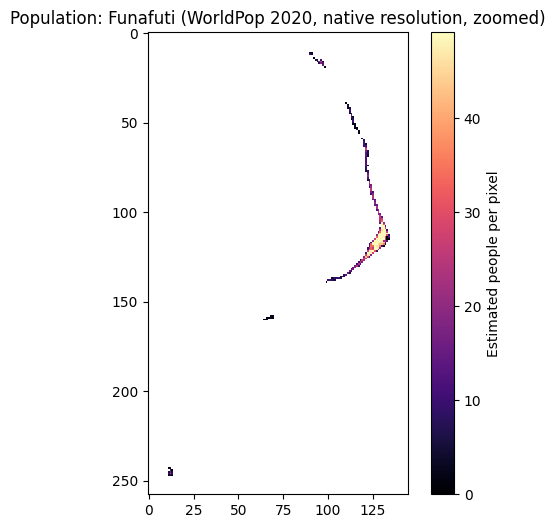

In [10]:
pop_valid_mask = (pop != pop_nodata) if pop_nodata is not None else np.ones_like(pop, dtype=bool)
prows, pcols = np.where(pop_valid_mask)
ppad = max(10, int(0.05 * max(prows.max() - prows.min(), pcols.max() - pcols.min())))
prow_min, prow_max = max(0, prows.min() - ppad), min(pop.shape[0], prows.max() + ppad)
pcol_min, pcol_max = max(0, pcols.min() - ppad), min(pop.shape[1], pcols.max() + ppad)

fig, ax = plt.subplots(figsize=(6, 6))
pop_display = np.where(pop == pop_nodata, np.nan, pop)
pop_cropped = pop_display[prow_min:prow_max, pcol_min:pcol_max]
im = ax.imshow(pop_cropped, cmap="magma", interpolation="nearest")
ax.set_title("Population: Funafuti (WorldPop 2020, native resolution, zoomed)")
plt.colorbar(im, ax=ax, label="Estimated people per pixel")
plt.show()

## 8. Context statistics

Checks the reference file used for non-model numbers in the website.


In [11]:
with open(CONTEXT_STATS_PATH, encoding="utf-8") as f:
    context = json.load(f)

expected_context = {
    "tuvalu_resident_population_2022_23": 10632,
    "funafuti_resident_population_2022_23": 6602,
    "tuvalu_resident_population_2017": 10507,
    "funafuti_resident_population_2017": 6320,
    "tuvalu_mean_elevation_msl_m": 1.55,
    "funafuti_mean_elevation_msl_m": 1.48,
    "funafuti_max_elevation_lidar_m": 6.93,
    "nz_tuvaluan_ethnic_group_2013": 3537,
    "nz_tuvaluan_ethnic_group_2018": 4653,
    "nz_tuvaluan_ethnic_group_2023": 6585,
    "auckland_region_share_tuvaluan_2023_pct": 67.1,
    "pac_tuvalu_places_2026": 75,
}

missing_context_keys = [k for k in expected_context if k not in context]
record_check(
    "context_keys",
    "PASS" if not missing_context_keys else "FAIL",
    "Context statistics fields",
    "all required fields present" if not missing_context_keys
    else f"missing: {missing_context_keys}",
    blocking=True,
)

metadata_failures = []
value_failures = []

if not missing_context_keys:
    for key, expected_value in expected_context.items():
        item = context[key]

        if item.get("value") != expected_value:
            value_failures.append(
                f"{key}: expected {expected_value}, found {item.get('value')}"
            )

        for field in ["source", "source_type", "verified", "verified_date", "verification_method"]:
            if field not in item or item[field] in ("", None):
                metadata_failures.append(f"{key}: missing {field}")

        if item.get("verified") is not True:
            metadata_failures.append(f"{key}: verified is not true")

    record_check(
        "context_values",
        "PASS" if not value_failures else "FAIL",
        "Verified context values",
        "all values match the reviewed source register"
        if not value_failures else "; ".join(value_failures),
        blocking=True,
    )

    record_check(
        "context_provenance",
        "PASS" if not metadata_failures else "FAIL",
        "Context source metadata",
        "source, source type and verification metadata present"
        if not metadata_failures else "; ".join(metadata_failures),
        blocking=True,
    )

    tuvalu_2223 = context["tuvalu_resident_population_2022_23"]["value"]
    funafuti_2223 = context["funafuti_resident_population_2022_23"]["value"]
    funafuti_share = funafuti_2223 / tuvalu_2223 * 100

    nz_2013 = context["nz_tuvaluan_ethnic_group_2013"]["value"]
    nz_2023 = context["nz_tuvaluan_ethnic_group_2023"]["value"]
    nz_growth = (nz_2023 - nz_2013) / nz_2013 * 100

    record_check(
        "context_arithmetic",
        "PASS" if abs(funafuti_share - 62.1) < 0.1 and abs(nz_growth - 86.17) < 0.1 else "FAIL",
        "Context statistics arithmetic",
        f"Funafuti share={funafuti_share:.1f}% | NZ 2013-2023 growth={nz_growth:.2f}%",
        blocking=True,
    )

PASS  Context statistics fields  -- all required fields present
PASS  Verified context values  -- all values match the reviewed source register
PASS  Context source metadata  -- source, source type and verification metadata present
PASS  Context statistics arithmetic  -- Funafuti share=62.1% | NZ 2013-2023 growth=86.17%


## 9. Summary

In [12]:
dem_src.close()
pop_src.close()

print("=" * 70)
print("Validation summary")
print("=" * 70)

for result in results.values():
    print(f"  {result['status']:<4}  {result['label']}")
    if result["detail"]:
        print(f"        {result['detail']}")

blocking_failures = [
    result for result in results.values()
    if result["blocking"] and result["status"] == "FAIL"
]
warnings = [result for result in results.values() if result["status"] == "WARN"]
infos = [result for result in results.values() if result["status"] == "INFO"]

print()
if blocking_failures:
    print(f"Blocking checks: FAILED ({len(blocking_failures)})")
    for result in blocking_failures:
        print(f"  - {result['label']}")
    print("Do not proceed to the formal analysis until the blocking failures are resolved.")
else:
    print("Blocking checks: PASSED")
    if warnings:
        print(f"Methodological warnings: {len(warnings)}")
        print("Ready for analysis; retain the listed warnings in the methodology.")
    else:
        print("Methodological warnings: 0")
        print("Ready for the formal analysis.")

if infos:
    print(f"Informational differences handled downstream: {len(infos)}")

print()
print("Reference years to keep explicit in the site and documentation:")
print("  - Sea level anomalies: 1993-2023 (official annual data)")
print("  - Population (WorldPop): 2020 (modelled estimate)")
print("  - Stats NZ Census: 2023")
print("  Context census/statistics: use the reference period stored in context_stats.json")

Validation summary
  INFO  Native coordinate reference systems
        DEM: EPSG:3832 | Population: EPSG:4326 | different by design; population is reprojected to the DEM grid during analysis
  PASS  Geographic extents overlap (compared in a common CRS)
        DEM bounds (EPSG:3832): (3181246.66, -999388.9, 3302643.48, -889857.48) | Population bounds reprojected to EPSG:3832: (3181232.59, -1013153.41, 3302663.6, -889847.72)
  INFO  Native raster grid alignment
        DEM resolution: (30.819197846428175, 30.819197846428498) (EPSG:3832) | Population resolution: (0.00083333333, 0.00083333333) (EPSG:4326) | different by design; nearest-neighbour reprojection/resampling is required downstream
  WARN  Elevation range
        ASTER max 41.00 m is well above the 6.93 m Funafuti LiDAR maximum reported by Wandres et al. (2024). Treat threshold results as screening-level elevation exposure.
  PASS  Native-resolution WorldPop total is a reasonable order of magnitude
        Raster total populatio

## 10. Next step

If there are no blocking failures, run `01_flood_exposure_analysis.ipynb`.

A warning on ASTER vertical accuracy is expected for this site and should stay
visible in the final methodology.